In [ ]:
import logging
import os
import warnings

# Molab's server image may expose a CUDA JAX plugin even when the temporary
# server has no usable GPU. Keep this construction-only notebook on CPU and
# prevent that unused plugin from probing CUDA during discovery.
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_SKIP_CUDA_CONSTRAINTS_CHECK"] = "1"

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.CRITICAL)

import bambi as bmb
import jax
import marimo as mo
import numpy as np
import pandas as pd
import pymc as pm
from formulae import design_matrices

import hssm
from hssm.param.parameterization_check import find_disconnected_free_rvs

logging.getLogger("hssm").setLevel(logging.ERROR)
hssm.set_floatX("float64")
pd.set_option("display.max_rows", 20)
assert jax.default_backend() == "cpu"

In [ ]:
mo.md(f"""
# Random-slope safe priors and parameterization diagnostics

This notebook validates the corrected `prior_settings="safe"` behavior for
a regression containing the same slopes at the population and participant
levels. It then recreates the old bug explicitly, without relying on an
affected HSSM installation. It uses **HSSM {hssm.__version__}** and
**Bambi {bmb.__version__}** from the active environment.

The hosted environment is pinned to the reviewed HSSM #1224 implementation
at `944eacb0`. When opened from an HSSM checkout with `--no-sandbox`, the
notebook instead validates that checkout.

This construction-only notebook explicitly uses the **{jax.default_backend()}**
JAX backend so it also runs on Molab servers whose base image exposes an
unavailable CUDA plugin.

We will establish four things without running MCMC:

1. the common and participant-specific component designs have their expected
   maximal ranks, with the usual fixed/random column overlap;
2. corrected safe defaults structurally match common and group terms and
   fix every participant-level mean at zero;
3. manually recreating the old free-mean priors produces disconnected means
   when non-centered and a location ridge when centered; and
4. corrected safe defaults agree with the explicit zero-mean reference.
""")

# Random-slope safe priors and parameterization diagnostics

This notebook validates the corrected `prior_settings="safe"` behavior for
a regression containing the same slopes at the population and participant
levels. It then recreates the old bug explicitly, without relying on an
affected HSSM installation. It uses **HSSM 0.4.0** and
**Bambi 0.20.0** from the active environment.

The hosted environment is pinned to the reviewed HSSM #1224 implementation
at `944eacb0`. When opened from an HSSM checkout with `--no-sandbox`, the
notebook instead validates that checkout.

This construction-only notebook explicitly uses the **cpu**
JAX backend so it also runs on Molab servers whose base image exposes an
unavailable CUDA plugin.

We will establish four things without running MCMC:

1. the common and participant-specific component designs have their expected
   maximal ranks, with the usual fixed/random column overlap;
2. corrected safe defaults structurally match common and group terms and
   fix every participant-level mean at zero;
3. manually recreating the old free-mean priors produces disconnected means
   when non-centered and a location ridge when centered; and
4. corrected safe defaults agree with the explicit zero-mean reference.

In [ ]:
rows = []
for participant in range(2):
    for cell, (block, task) in enumerate([(-1, -1), (-1, 1), (1, -1), (1, 1)]):
        rows.append(
            {
                "rt": 0.45 + 0.03 * cell + 0.01 * participant,
                "response": (-1, 1, 1, -1)[cell],
                "blocktype2_num": block,
                "task_num": task,
                "participant_id": f"p{participant}",
            }
        )

data = pd.DataFrame(rows)
formula = (
    "v ~ 1 + blocktype2_num*task_num + (1 + blocktype2_num*task_num|participant_id)"
)

## 1. Tiny balanced 2x2 dataset

There are two participants and exactly one observation in each of the four
`block x task` cells. Both predictors use the forum post's numeric -1/+1
coding.

In [ ]:
data

,rt,response,blocktype2_num,task_num,participant_id
0,0.45,-1,-1,-1,p0
1,0.48,1,-1,1,p0
2,0.51,1,1,-1,p0
3,0.54,-1,1,1,p0
4,0.46,-1,-1,-1,p1
5,0.49,1,-1,1,p1
6,0.52,1,1,-1,p1
7,0.55,-1,1,1,p1


In [ ]:
rhs = formula.split("~", maxsplit=1)[1]
matrices = design_matrices(f"response ~ {rhs}", data=data)
common_matrix = np.asarray(matrices.common.design_matrix)
group_matrix = matrices.group.design_matrix.toarray()
combined_matrix = np.column_stack([common_matrix, group_matrix])

design_rank_table = pd.DataFrame(
    [
        {
            "design": "common (population)",
            "rows": common_matrix.shape[0],
            "columns": common_matrix.shape[1],
            "rank": np.linalg.matrix_rank(common_matrix),
        },
        {
            "design": "group-specific (both participants)",
            "rows": group_matrix.shape[0],
            "columns": group_matrix.shape[1],
            "rank": np.linalg.matrix_rank(group_matrix),
        },
        {
            "design": "combined [common | group-specific]",
            "rows": combined_matrix.shape[0],
            "columns": combined_matrix.shape[1],
            "rank": np.linalg.matrix_rank(combined_matrix),
        },
    ]
)

assert np.linalg.matrix_rank(common_matrix) == 4
assert np.linalg.matrix_rank(group_matrix) == 8
assert np.linalg.matrix_rank(combined_matrix) == 8

## 2. The component designs have their expected ranks

With -1/+1 coding, the common-effect columns are `1`, `block`, `task`, and
`block:task`. They form a four-column Hadamard matrix within each complete
participant, so the common design has rank 4. The participant-specific
design has four independent columns for each participant and rank 8.

The combined 8-by-12 matrix has rank 8 because each common column is the sum
of its two participant-specific counterparts. That overlap is standard in a
mixed model: the common coefficient owns the population location and the
zero-mean group coefficients are participant deviations. The legacy bug
added another free population mean to each deviation distribution, which is
the extra location exposed below.

In [ ]:
design_rank_table

,design,rows,columns,rank
0,common (population),8,4,4
1,group-specific (both participants),8,8,8
2,combined [common | group-specific],8,12,8


In [ ]:
matcher_rows = []
for group_name, term in matrices.group.terms.items():
    matcher_rows.append(
        {
            "group term": group_name,
            "group expression": term.expr.name,
            "full group name in common terms": group_name in matrices.common.terms,
            "expression in common terms": term.expr.name in matrices.common.terms,
        }
    )

matcher_table = pd.DataFrame(matcher_rows)

## 3. The exact matching error

Affected HSSM versions compare the complete group name with the common-term
keys. A name such as `blocktype2_num|participant_id` cannot equal
`blocktype2_num`. Formulae exposes the correct structural name as
`term.expr.name`, which fixed versions now use.

The two Boolean columns below reproduce the affected and corrected matching
rules. The full names never match; every underlying expression does.

In [ ]:
matcher_table

,group term,group expression,full group name in common terms,expression in common terms
0,1|participant_id,Intercept,False,True
1,blocktype2_num|participant_id,blocktype2_num,False,True
2,task_num|participant_id,task_num,False,True
3,blocktype2_num:task_num|participant_id,blocktype2_num:task_num,False,True


In [ ]:
def zero_mean_participant_prior():
    """Return the corrected scalar-zero participant prior."""
    return {
        "name": "Normal",
        "mu": 0.0,
        "sigma": {
            "name": "Weibull",
            "alpha": 1.5,
            "beta": 0.3,
        },
    }


def legacy_free_mean_participant_prior():
    """Return the formerly generated free-mean participant prior."""
    return {
        "name": "Normal",
        "mu": {
            "name": "Normal",
            "mu": 0.0,
            "sigma": 0.25,
        },
        "sigma": {
            "name": "Weibull",
            "alpha": 1.5,
            "beta": 0.3,
        },
    }


group_terms = [
    "1|participant_id",
    "blocktype2_num|participant_id",
    "task_num|participant_id",
    "blocktype2_num:task_num|participant_id",
]
group_slope_terms = group_terms[1:]
workaround_priors = {term: zero_mean_participant_prior() for term in group_terms}
legacy_priors = {
    term: legacy_free_mean_participant_prior() for term in group_slope_terms
}


def build_model(prior=None, noncentered=True):
    """Construct one model variant without sampling."""
    return hssm.HSSM(
        data=data,
        model="ddm",
        include=[
            {
                "name": "v",
                "formula": formula,
                "prior": prior,
            }
        ],
        prior_settings="safe",
        z=0.5,
        p_outlier=0.0,
        noncentered=noncentered,
        process_initvals=False,
    )

In [ ]:
safe_noncentered_model = build_model(noncentered=True)
safe_centered_model = build_model(noncentered=False)
legacy_noncentered_model = build_model(
    prior=legacy_priors,
    noncentered=True,
)
legacy_centered_model = build_model(
    prior=legacy_priors,
    noncentered=False,
)
workaround_model = build_model(
    prior=workaround_priors,
    noncentered=True,
)

In [ ]:
def group_prior_table(model):
    """Summarize the group priors generated for one model."""
    rows = []
    for term_name, prior in model.params["v"].prior.items():
        if "|" not in term_name:
            continue
        mu = prior.args["mu"]
        mu_is_estimated = isinstance(mu, bmb.Prior)
        rows.append(
            {
                "term": term_name,
                "mu": repr(mu),
                "mu is estimated": mu_is_estimated,
                "mu is scalar zero": (
                    not mu_is_estimated
                    and np.asarray(mu).ndim == 0
                    and bool(np.all(np.asarray(mu) == 0.0))
                ),
                "sigma": repr(prior.args["sigma"]),
            }
        )
    return pd.DataFrame(rows)


safe_prior_table = group_prior_table(safe_noncentered_model)
legacy_prior_table = group_prior_table(legacy_noncentered_model)
workaround_prior_table = group_prior_table(workaround_model)
prior_comparison_table = pd.concat(
    [
        safe_prior_table.assign(specification="corrected safe defaults"),
        legacy_prior_table.assign(specification="manual legacy priors"),
        workaround_prior_table.assign(specification="explicit zero-mean reference"),
    ],
    ignore_index=True,
)
prior_comparison_table = prior_comparison_table[
    ["specification", *safe_prior_table.columns]
]
safe_means_match_workaround = (
    safe_prior_table.set_index("term")["mu"].to_dict()
    == workaround_prior_table.set_index("term")["mu"].to_dict()
)
assert safe_means_match_workaround
assert not safe_prior_table["mu is estimated"].any()
assert safe_prior_table["mu is scalar zero"].all()

## 4. Prove the corrected defaults and recreate the old priors

Corrected safe defaults give every matching participant-level coefficient a
scalar `mu=0.0`. The explicit zero-mean reference is the workaround required
by affected releases, and the notebook asserts that its means agree exactly
with the corrected defaults.

The legacy option is constructed manually: only the three random slopes are
assigned estimated `Normal(0, 0.25)` means. This recreates the malformed
priors once generated by affected HSSM versions while the notebook itself
continues to run on fixed HSSM code.

In Molab, use the selector for a focused view. The full static comparison is
included underneath it for the published documentation.

In [ ]:
prior_view = mo.ui.dropdown(
    options={
        "Corrected HSSM safe defaults": "safe",
        "Manually recreated legacy priors": "legacy",
        "Explicit zero-mean reference": "workaround",
    },
    value="Corrected HSSM safe defaults",
    label="Prior specification",
)
prior_view

&lt;marimo-dropdown data-initial-value=&#x27;[&amp;quot;Corrected HSSM safe defaults&amp;quot;]&#x27; data-label=&#x27;&amp;quot;&amp;#92;u003cspan class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;#92;u003e&amp;#92;u003cspan class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;#92;u003ePrior specification&amp;#92;u003c/span&amp;#92;u003e&amp;#92;u003c/span&amp;#92;u003e&amp;quot;&#x27; data-options=&#x27;[&amp;quot;Corrected HSSM safe defaults&amp;quot;,&amp;quot;Manually recreated legacy priors&amp;quot;,&amp;quot;Explicit zero-mean reference&amp;quot;]&#x27; data-allow-select-none=&#x27;false&#x27; data-searchable=&#x27;false&#x27; data-full-width=&#x27;false&#x27; data-disabled=&#x27;false&#x27;&gt;&lt;/marimo-dropdown&gt;

In [ ]:
_prior_tables = {
    "safe": safe_prior_table,
    "legacy": legacy_prior_table,
    "workaround": workaround_prior_table,
}
selected_prior_table = _prior_tables[prior_view.value]
selected_prior_table

,term,mu,mu is estimated,mu is scalar zero,sigma
0,1|participant_id,array(0.),False,True,"Weibull(alpha: 1.5, beta: 0.3)"
1,blocktype2_num|participant_id,array(0.),False,True,"Weibull(alpha: 1.5, beta: 0.3)"
2,task_num|participant_id,array(0.),False,True,"Weibull(alpha: 1.5, beta: 0.3)"
3,blocktype2_num:task_num|participant_id,array(0.),False,True,"Weibull(alpha: 1.5, beta: 0.3)"


### Static prior comparison

Every corrected-safe and explicit-reference mean is the scalar zero. The
manual legacy rows make the three estimated slope means explicit.

In [ ]:
prior_comparison_table

,specification,term,mu,mu is estimated,mu is scalar zero,sigma
0,corrected safe defaults,1|participant_id,array(0.),False,True,"Weibull(alpha: 1.5, beta: 0.3)"
1,corrected safe defaults,blocktype2_num|participant_id,array(0.),False,True,"Weibull(alpha: 1.5, beta: 0.3)"
2,corrected safe defaults,task_num|participant_id,array(0.),False,True,"Weibull(alpha: 1.5, beta: 0.3)"
3,corrected safe defaults,blocktype2_num:task_num|participant_id,array(0.),False,True,"Weibull(alpha: 1.5, beta: 0.3)"
4,manual legacy priors,1|participant_id,array(0.),False,True,"Weibull(alpha: 1.5, beta: 0.3)"
5,manual legacy priors,blocktype2_num|participant_id,"Normal(mu: 0.0, sigma: 0.25)",True,False,"Weibull(alpha: 1.5, beta: 0.3)"
6,manual legacy priors,task_num|participant_id,"Normal(mu: 0.0, sigma: 0.25)",True,False,"Weibull(alpha: 1.5, beta: 0.3)"
7,manual legacy priors,blocktype2_num:task_num|participant_id,"Normal(mu: 0.0, sigma: 0.25)",True,False,"Weibull(alpha: 1.5, beta: 0.3)"
8,explicit zero-mean reference,1|participant_id,array(0.),False,True,"Weibull(alpha: 1.5, beta: 0.3)"
9,explicit zero-mean reference,blocktype2_num|participant_id,array(0.),False,True,"Weibull(alpha: 1.5, beta: 0.3)"


In [ ]:
safe_disconnected = find_disconnected_free_rvs(safe_noncentered_model.pymc_model)
safe_centered_disconnected = find_disconnected_free_rvs(safe_centered_model.pymc_model)
legacy_disconnected = find_disconnected_free_rvs(legacy_noncentered_model.pymc_model)
legacy_centered_disconnected = find_disconnected_free_rvs(
    legacy_centered_model.pymc_model
)
workaround_disconnected = find_disconnected_free_rvs(workaround_model.pymc_model)

disconnected_by_graph = {
    "safe_noncentered": safe_disconnected,
    "safe_centered": safe_centered_disconnected,
    "legacy_noncentered": legacy_disconnected,
    "legacy_centered": legacy_centered_disconnected,
    "workaround": workaround_disconnected,
}

graph_table = pd.DataFrame(
    [
        {
            "prior specification": "corrected safe defaults",
            "parameterization": "non-centered",
            "disconnected free RVs": ", ".join(safe_disconnected) or "none",
            "count": len(safe_disconnected),
            "diagnosis": "intended model",
        },
        {
            "prior specification": "corrected safe defaults",
            "parameterization": "centered",
            "disconnected free RVs": ", ".join(safe_centered_disconnected) or "none",
            "count": len(safe_centered_disconnected),
            "diagnosis": "intended model",
        },
        {
            "prior specification": "manual legacy free means",
            "parameterization": "non-centered",
            "disconnected free RVs": ", ".join(legacy_disconnected) or "none",
            "count": len(legacy_disconnected),
            "diagnosis": "orphan means",
        },
        {
            "prior specification": "manual legacy free means",
            "parameterization": "centered",
            "disconnected free RVs": ", ".join(legacy_centered_disconnected) or "none",
            "count": len(legacy_centered_disconnected),
            "diagnosis": "fixed/group-mean location ridge",
        },
        {
            "prior specification": "explicit zero-mean reference",
            "parameterization": "non-centered",
            "disconnected free RVs": ", ".join(workaround_disconnected) or "none",
            "count": len(workaround_disconnected),
            "diagnosis": "intended model",
        },
    ]
)

_expected_legacy_orphans = {
    "v_blocktype2_num|participant_id_mu",
    "v_task_num|participant_id_mu",
    "v_blocktype2_num:task_num|participant_id_mu",
}
_safe_group_means = {
    name
    for name in safe_noncentered_model.pymc_model.named_vars
    if "|participant_id_mu" in name
}
_safe_centered_group_means = {
    name
    for name in safe_centered_model.pymc_model.named_vars
    if "|participant_id_mu" in name
}
_legacy_centered_group_means = {
    name
    for name in legacy_centered_model.pymc_model.named_vars
    if "|participant_id_mu" in name
}
_workaround_group_means = {
    name
    for name in workaround_model.pymc_model.named_vars
    if "|participant_id_mu" in name
}
assert safe_disconnected == []
assert safe_centered_disconnected == []
assert set(legacy_disconnected) == _expected_legacy_orphans
assert legacy_centered_disconnected == []
assert workaround_disconnected == []
assert _safe_group_means == set()
assert _safe_centered_group_means == set()
assert _legacy_centered_group_means == _expected_legacy_orphans
assert _workaround_group_means == set()

## 5. What happens to the generated means

Corrected HSSM safe defaults create no free participant-level means, under
either parameterization. The explicit zero-mean reference has the same
clean result.

In the manually recreated legacy case, Bambi's non-centered group term is
`offset * sigma`; it does not add `mu`. The three supplied slope means remain
free random variables without a path to the likelihood. Centering connects
those means to the group distributions, but produces the location ridge
derived below rather than repairing the model.

In [ ]:
graph_table

,prior specification,parameterization,disconnected free RVs,count,diagnosis
0,corrected safe defaults,non-centered,none,0,intended model
1,corrected safe defaults,centered,none,0,intended model
2,manual legacy free means,non-centered,"v_blocktype2_num|participant_id_mu, v_task_num|participant_id_mu, v_blocktype2_num:task_num|participant_id_mu",3,orphan means
3,manual legacy free means,centered,none,0,fixed/group-mean location ridge
4,explicit zero-mean reference,non-centered,none,0,intended model


In [ ]:
assert safe_means_match_workaround
matcher_status = mo.callout(
    "Validated: corrected safe defaults are structurally matched, use scalar "
    "zero means, agree with the explicit reference, and create no disconnected "
    "means under either parameterization.",
    kind="success",
)
matcher_status

## 6. Inspect the actual PyMC model graphs

These are the graphs PyMC builds, not hand-drawn summaries. Follow the
arrows to the observed `rt,response` node:

- **red** nodes are free random variables with no path to the likelihood;
- **amber** nodes are estimated participant-level population means; and
- **blue** nodes are the matching common slopes.

The corrected-safe graph omits the unintended `*_mu` nodes. The manually
recreated legacy non-centered graph has three isolated red means. Centering
those same malformed priors connects the amber means, but each then competes
with a blue common slope for the same population location.

The published documentation keeps the three diagnostically important graph
snapshots below. In the [live Molab notebook](https://molab.marimo.io/github/lnccbrown/HSSM/blob/main/docs/tutorials/random_slope_safe_priors.py),
use the selector to inspect all five models, including the centered safe
defaults and the explicit zero-mean reference.

In [ ]:
graph_view = mo.ui.dropdown(
    options={
        "Corrected safe defaults, non-centered": "safe_noncentered",
        "Corrected safe defaults, centered": "safe_centered",
        "Manual legacy priors, non-centered": "legacy_noncentered",
        "Manual legacy priors, centered": "legacy_centered",
        "Explicit zero-mean reference": "workaround",
    },
    value="Corrected safe defaults, non-centered",
    label="Model graph",
)
graph_view

&lt;marimo-dropdown data-initial-value=&#x27;[&amp;quot;Corrected safe defaults, non-centered&amp;quot;]&#x27; data-label=&#x27;&amp;quot;&amp;#92;u003cspan class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;#92;u003e&amp;#92;u003cspan class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;#92;u003eModel graph&amp;#92;u003c/span&amp;#92;u003e&amp;#92;u003c/span&amp;#92;u003e&amp;quot;&#x27; data-options=&#x27;[&amp;quot;Corrected safe defaults, non-centered&amp;quot;,&amp;quot;Corrected safe defaults, centered&amp;quot;,&amp;quot;Manual legacy priors, non-centered&amp;quot;,&amp;quot;Manual legacy priors, centered&amp;quot;,&amp;quot;Explicit zero-mean reference&amp;quot;]&#x27; data-allow-select-none=&#x27;false&#x27; data-searchable=&#x27;false&#x27; data-full-width=&#x27;false&#x27; data-disabled=&#x27;false&#x27;&gt;&lt;/marimo-dropdown&gt;

In [ ]:
_models = {
    "safe_noncentered": safe_noncentered_model,
    "safe_centered": safe_centered_model,
    "legacy_noncentered": legacy_noncentered_model,
    "legacy_centered": legacy_centered_model,
    "workaround": workaround_model,
}
_common_slope_names = {
    "v_blocktype2_num",
    "v_task_num",
    "v_blocktype2_num:task_num",
}


def make_model_graph(graph_key):
    """Render one model graph with diagnostic node colors."""
    _selected_model = _models[graph_key]
    _disconnected_names = set(disconnected_by_graph[graph_key])
    _group_mean_names = {
        _name
        for _name in _selected_model.pymc_model.named_vars
        if "|participant_id_mu" in _name
    }

    def _free_rv_formatter(variable):
        _operator_name = getattr(variable.owner.op, "name", None)
        _distribution_name = (
            _operator_name[0].upper() + _operator_name[1:]
            if _operator_name
            else variable.owner.op.__class__.__name__.removesuffix("RV")
        )
        _attributes = {
            "shape": "ellipse",
            "label": f"{variable.name}\n~\n{_distribution_name}",
        }

        if variable.name in _disconnected_names:
            _attributes.update(
                color="#b42318",
                fillcolor="#fee4e2",
                fontcolor="#912018",
                penwidth="3",
                style="filled",
            )
        elif variable.name in _group_mean_names:
            _attributes.update(
                color="#b54708",
                fillcolor="#fef0c7",
                fontcolor="#93370d",
                penwidth="2",
                style="filled",
            )
        elif variable.name in _common_slope_names:
            _attributes.update(
                color="#175cd3",
                fillcolor="#d1e9ff",
                fontcolor="#1849a9",
                penwidth="2",
                style="filled",
            )

        return _attributes

    return pm.model_to_graphviz(
        _selected_model.pymc_model,
        node_formatters={"Free Random Variable": _free_rv_formatter},
        graph_attr={"bgcolor": "transparent", "rankdir": "LR"},
    )

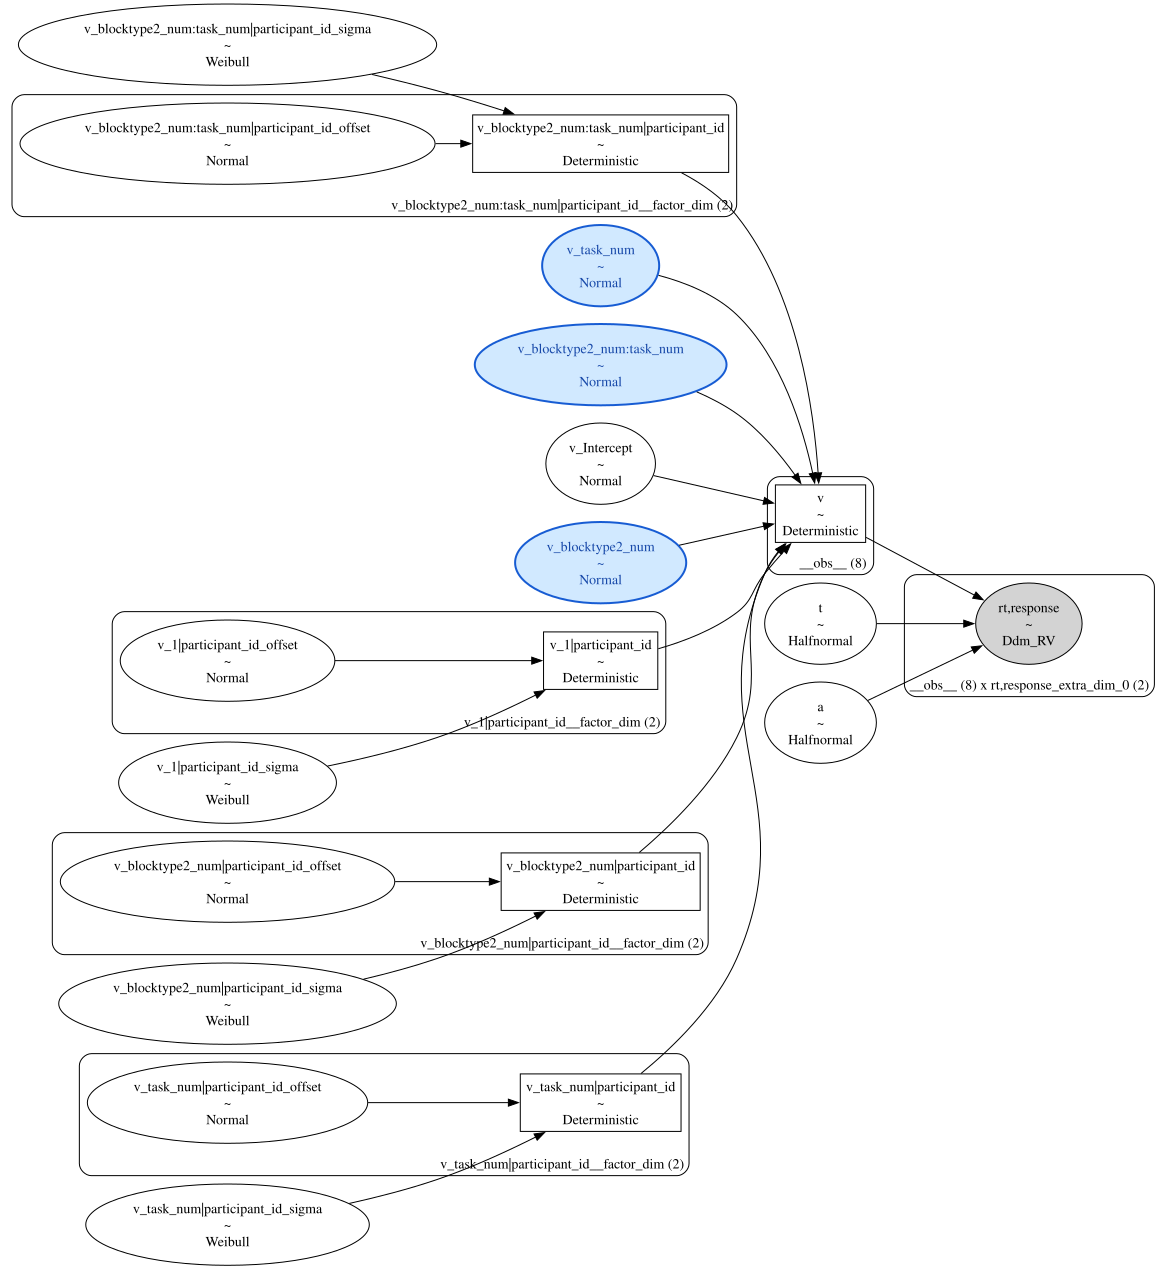

In [ ]:
selected_model_graph = make_model_graph(graph_view.value)
selected_model_graph

### Legacy free means, non-centered

Bambi creates the three slope-mean random variables but omits them from the
non-centered group coefficients. They are the isolated red nodes below.

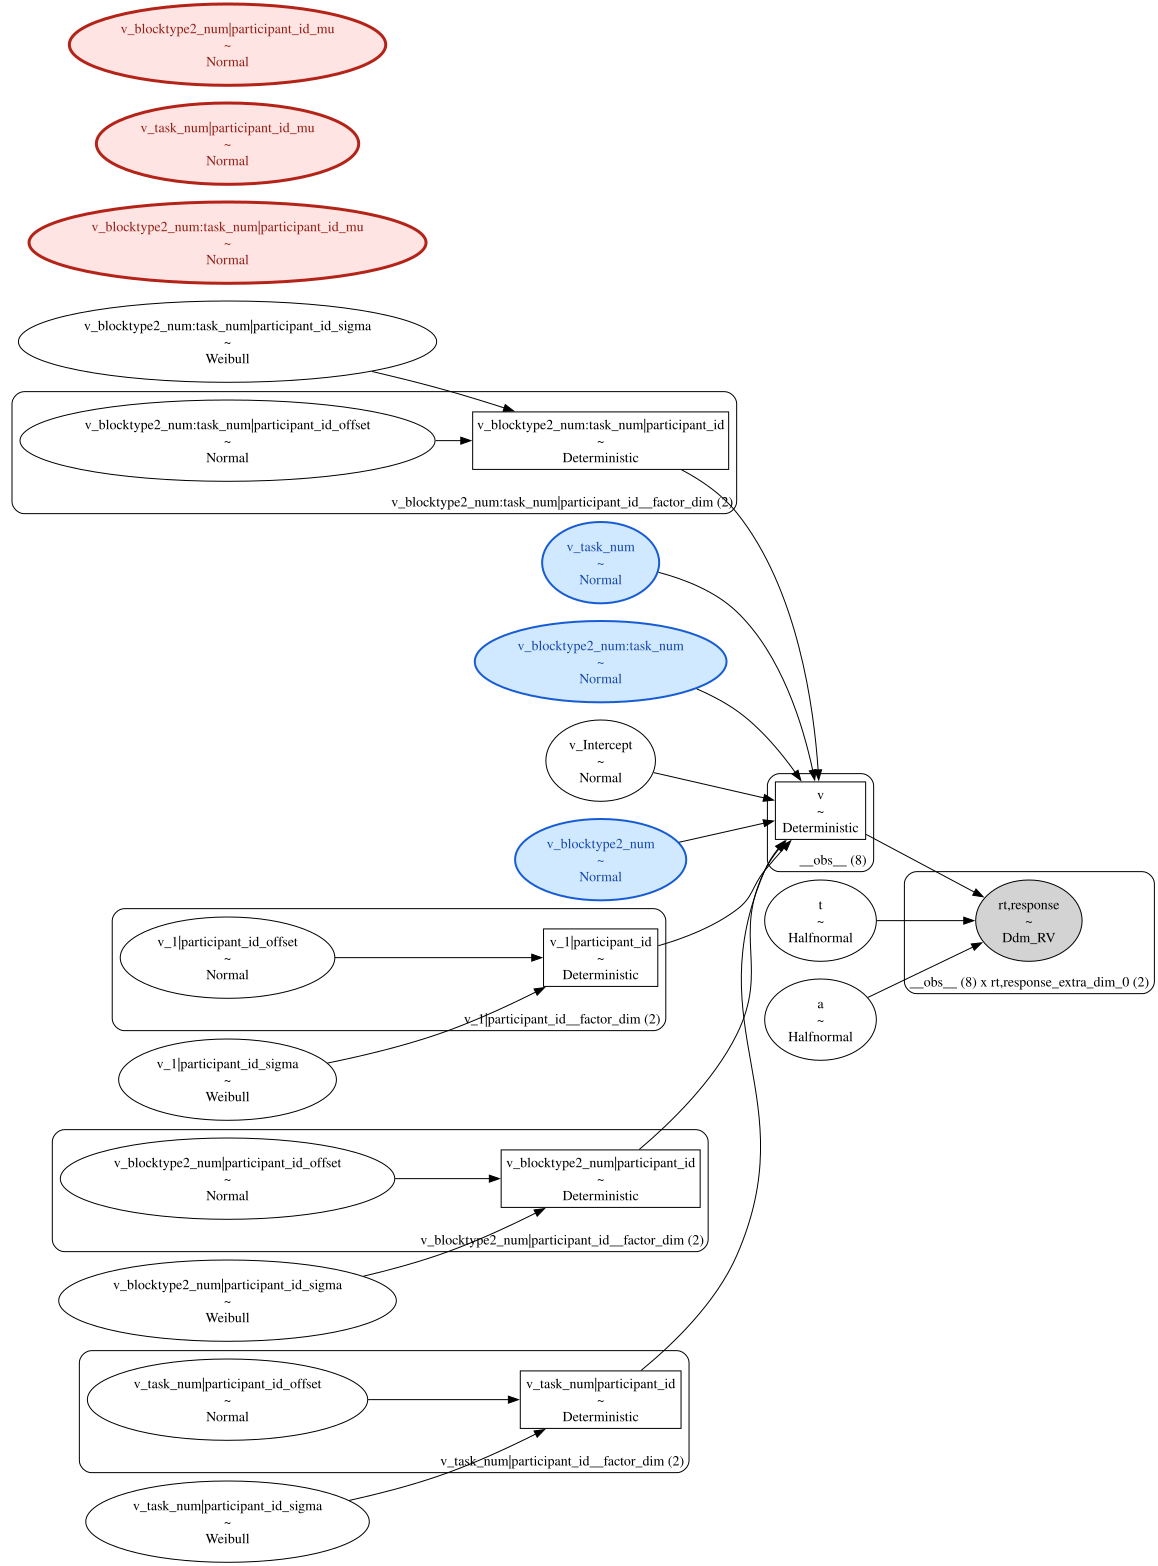

In [ ]:
legacy_noncentered_graph = make_model_graph("legacy_noncentered")
legacy_noncentered_graph

### Legacy free means, centered

Centering connects each amber group mean to the likelihood, but only through
the same slope direction as its blue common effect. The graph exposes the two
population-location paths; the algebra in the next section shows the ridge.

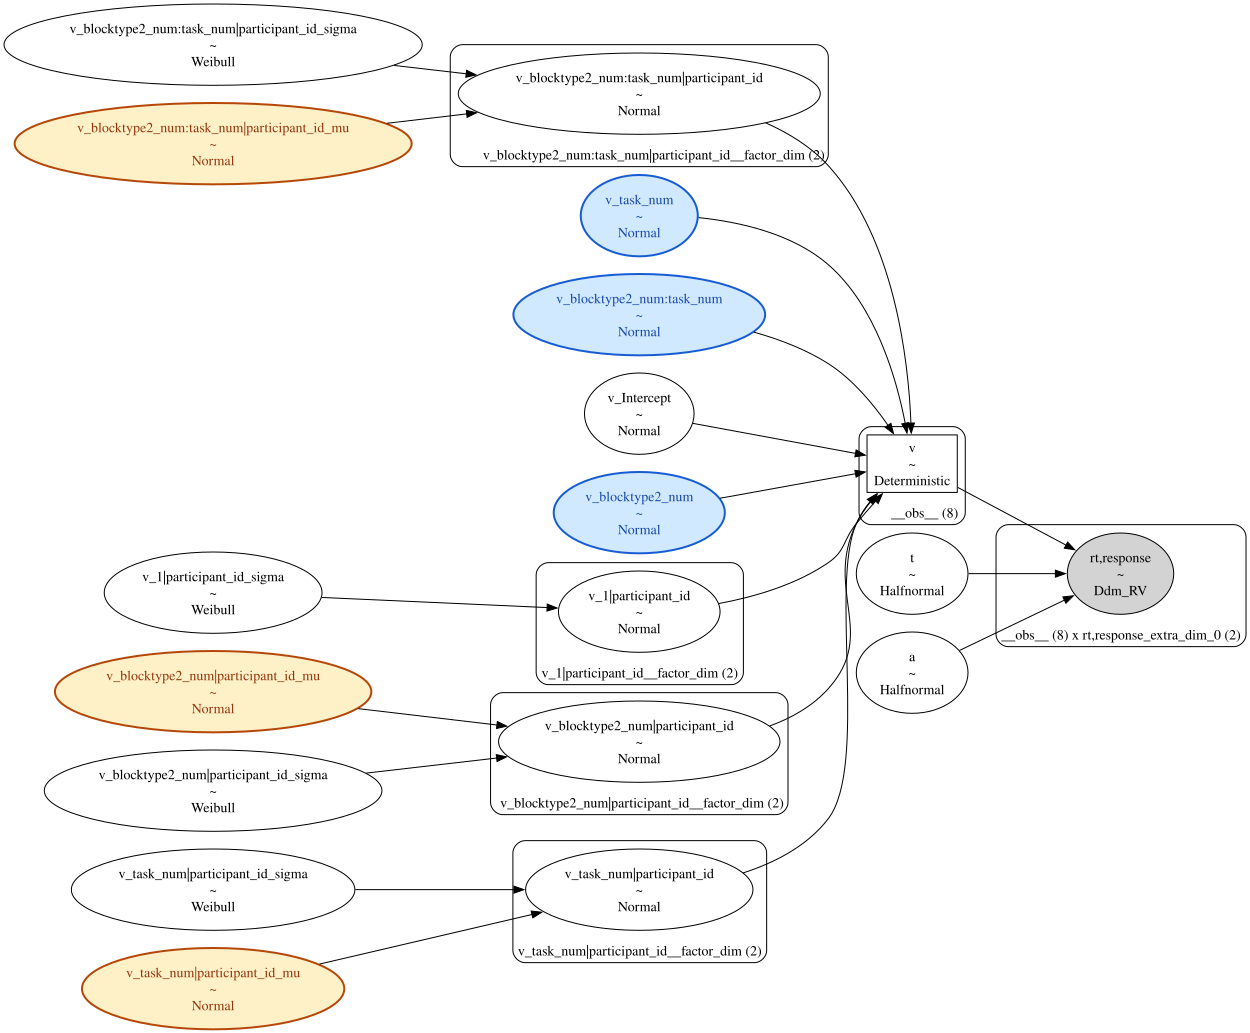

In [ ]:
legacy_centered_graph = make_model_graph("legacy_centered")
legacy_centered_graph

## 7. Why centering the manually recreated legacy model is not a fix

For slope (k) and participant (g), a centered group coefficient can be
written as

$$u_{kg} = \mu_k + \delta_{kg}.$$

When the formula also contains common slope $\beta_k$, its contribution to
the linear predictor is

$$\eta_i
  = \beta_k x_{ik} + u_{k,g(i)}x_{ik}
  = (\beta_k + \mu_k)x_{ik} + \delta_{k,g(i)}x_{ik}.$$

The data identify only the combined population location
$\beta_k + \mu_k$. Moving a constant from one to the other, while shifting
the participant coefficients consistently, leaves the likelihood and the
conditional group distribution unchanged. Their proper top-level priors may
make the posterior proper, but the two locations are not separately informed
by the data.

For the manually recreated free-mean priors, `noncentered=False` trades the
disconnected-variable symptom for a location ridge. Corrected safe defaults
keep the common slope and fix the group deviation mean at zero.

## 8. Compatibility workaround for affected releases

On an affected HSSM release, keep `noncentered=True` and explicitly provide
a scalar `mu=0.0` for every participant-level coefficient:

```python
def zero_mean_participant_prior():
    return {
        "name": "Normal",
        "mu": 0.0,
        "sigma": {
            "name": "Weibull",
            "alpha": 1.5,
            "beta": 0.3,
        },
    }

group_terms = [
    "1|participant_id",
    "blocktype2_num|participant_id",
    "task_num|participant_id",
    "blocktype2_num:task_num|participant_id",
]

priors = {
    term: zero_mean_participant_prior()
    for term in group_terms
}
```

Supply `priors` as the regression parameter's `prior` dictionary. The random
intercept was already zero-centered by affected safe defaults, but specifying
all four terms makes the model intent explicit and keeps the workaround
self-contained. On fixed HSSM versions, exact common/group matches receive
these scalar-zero means automatically; the explicit dictionary remains valid
but is no longer required.

## Takeaway

The common and participant-specific component designs have their expected
maximal ranks and standard mixed-model column overlap. Corrected HSSM safe
defaults match group expressions to common counterparts through Formulae
metadata, generate scalar-zero group means, and agree with the explicit
zero-mean reference.

The old pathology is reproduced independently by manually supplying its
free-mean slope priors: non-centering exposes three orphan variables, while
centering exposes the fixed/group-mean location ridge. For affected HSSM
releases, explicit zero-mean group priors remain the safe workaround shown
above.

Every group term in this tutorial has an exact common counterpart, so each
is a deviation whose generated mean must be zero. Truly group-only terms
follow a different ownership rule: HSSM preserves and centers one generated
location owner, but rejects multiple generated owners for the same exact
expression. The [link-functions tutorial](https://lnccbrown.github.io/HSSM/tutorials/link_functions/)
works through that distinction across identity and transformed links.

Relevant implementation discussions:

- [HSSM discussion #948](https://github.com/lnccbrown/HSSM/discussions/948)
- [HSSM issue #1224](https://github.com/lnccbrown/HSSM/issues/1224)
- [HSSM group-only location ownership #1225](https://github.com/lnccbrown/HSSM/issues/1225)
- [Bambi issue #1003](https://github.com/bambinos/bambi/issues/1003)
- [Formulae term structure](https://github.com/bambinos/formulae/blob/master/formulae/terms/terms.py)